# Fast.ai Unit 1 Mini Project: Painting Classifier Core
This is the central notebook for the Fast.ai Practical Deep Learning course **Unit 1 Mini Project**, which is an image classifier designed to classify paintings based on a small subset of well-known artists. These artists are primarily taken from the Impressionistic time period. This is the **local-only, file-based** version of this model, meaning it is not yet available for use in a web environment. 

In [11]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from fastai.vision.all import * # fastai image classification
!pip install -Uqq duckduckgo_search==5.3.1b1

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Define the dataset folder explicitly so the name is stable across cells
painting_data = Path('painting_data')
print('painting_data =', painting_data)
painting_data.mkdir(exist_ok=True, parents=True)

# Create a new folder containing the new images for training the second model version
painting_data_updated = Path('painting_data_updated')
print('painting_data_updated = ', painting_data_updated)
painting_data_updated.mkdir(exist_ok=True, parents=True)

painting_data = painting_data
painting_data_updated =  painting_data_updated


## Gather data and search for images
For this project we're going to use DuckDuckGo to find some images of Impressionistic paintings. First we'll pull down some sample images of Impressionistic painters, then download larger amounts of images for training the model. 

In [2]:
import time
from duckduckgo_search import DDGS
from fastcore.all import *

def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = list(ddgs.images(keywords, max_results=max_images))
        time.sleep(2)
        return [r['image'] for r in results]

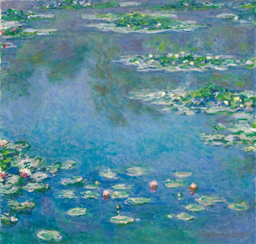

In [3]:
from fastdownload import download_url
from fastai.vision.all import *

# Test to see what kind of results we get when searching for Monet paintings
urls = search_images('monet painting', max_images=1)
urls[0]

dest = 'monet-test-1.jpg'
download_url(urls[0], dest, show_progress=False)

im = Image.open(dest)
im.to_thumb(256,256) # show a preview of the image

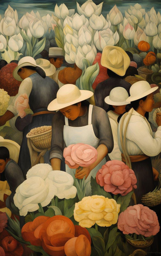

In [9]:
# Do the same thing with a variety of other Impressionistic artists before pulling down mass images to train
urls = search_images('diego rivera painting', max_images=1)
urls[0]

dest1 = 'rivera-test-1.jpg'
download_url(urls[0], dest1, show_progress=False)

im = Image.open(dest1)
im.to_thumb(256,256) # show a preview of the image

## Prepare to search and download mass images for training
For the second version of this model, **we take things a step further and incorporate some watermark-filtering techniques**. First, we exclude common stock photo sites like Getty and Alamy from all searches. Then, as a post-filter, we use a pretrained fast.ai vision learner to filter out images with watermarks and strips on them. Finally, this second version downloads **400** images per artist, into a separate folder as the first one.

In [12]:
# Create folders for the watermarked and clean images for the watermark-detector model
watermarked = Path('watermarked')
clean = Path('clean')
watermarked.mkdir(exist_ok=True, parents=True)
clean.mkdir(exist_ok=True, parents=True)

In [ ]:
# Begin training the watermark-detector model??? Still considering this as it's a lot of work to do manually???

In [20]:
# full list of artists: ARTIST_NAMES = 'monet', 'renoir', 'rivera', 'degas', 'morisot', 'cassatt', 'cezanne', 'van gogh', 'gauguin', 'manet', 'pissarro', 'seurat', 'toulouse-lautrec', 'whistler', 'turner', 'matisse', 'picasso', 'braque', 'mondrian', 'warhol'

def download_artist_images(artist_names: list, 
                           output_dir: Path = Path('painting_data_updated'),
                           images_per_artist: int = 400):
    """Reusable function to download images of paintings efficiently"""
    output_dir.mkdir(exist_ok=True, parents=True)
    
    for artist_name in artist_names:
        artist_dir = output_dir / artist_name
        artist_dir.mkdir(exist_ok=True, parents=True)
        
        urls = search_images(artist_name + ' painting -site:gettyimages.com -site:alamy.com -site:123rf.com', max_images=images_per_artist)

        download_images(artist_dir, urls=urls)
        print(f"Downloaded {len(urls)} images for {artist_name}")

# Pull down photos of the first 5 artists
artists_batch_1 = ['monet', 'renoir', 'rivera', 'degas', 'morisot']
download_artist_images(artists_batch_1)

Downloaded 306 images for monet
Downloaded 323 images for renoir
Downloaded 299 images for rivera
Downloaded 221 images for degas
Downloaded 261 images for morisot


In [21]:
# Pull down photos of the next 5 artists
artists_batch_2 = ['cassatt', 'cezanne', 'van gogh', 'gauguin', 'manet']
download_artist_images(artists_batch_2)

artists_batch_3 = ['pissarro', 'seurat', 'toulouse-lautrec', 'whistler', 'turner']
download_artist_images(artists_batch_3)

artists_batch_4 = ['matisse', 'picasso', 'braque', 'mondrian', 'warhol']
download_artist_images(artists_batch_4)

Downloaded 209 images for cassatt
Downloaded 164 images for cezanne
Downloaded 268 images for van gogh
Downloaded 257 images for gauguin
Downloaded 274 images for manet
Downloaded 257 images for pissarro
Downloaded 195 images for seurat
Downloaded 269 images for toulouse-lautrec
Downloaded 326 images for whistler
Downloaded 177 images for turner
Downloaded 311 images for matisse
Downloaded 262 images for picasso
Downloaded 151 images for braque
Downloaded 208 images for mondrian
Downloaded 305 images for warhol


## Train the model
We will now proceed to train a **resnet34** classifier model and see how it performs on the given data. The resnet34 classifier is one of the pretrained models offered by PyTorch, and we will create the model using a traditional DataBlock architecture.

In [22]:
# Check to see if any of the images failed to download properly
failed = verify_images(get_image_files(painting_data))
failed.map(painting_data.unlink)
len(failed)

0

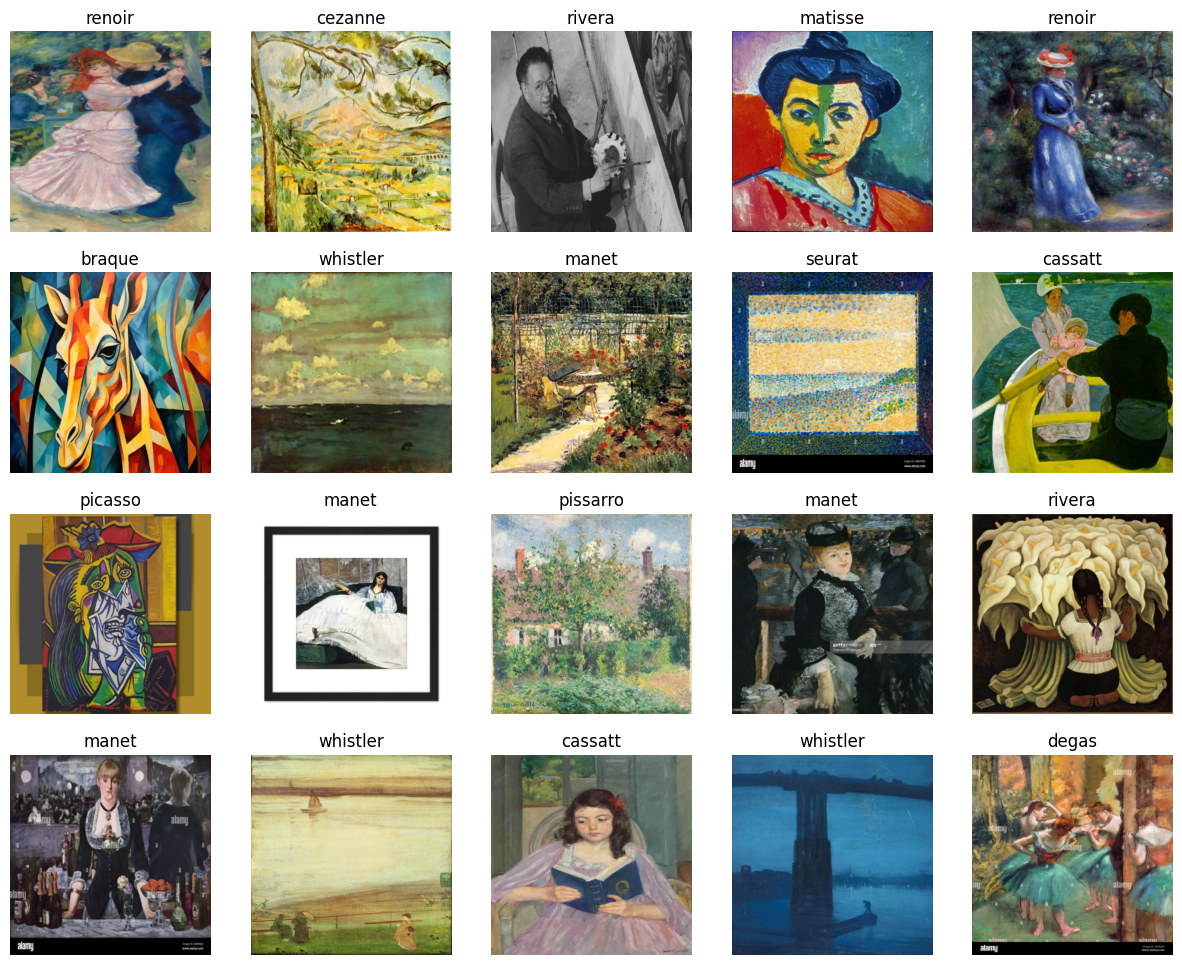

In [ ]:
# Create the Datablock
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # split 20% of the data off for validation
    get_y=parent_label,
    item_tfms=[Resize(384, method='squish')] # 384x384 image size for capturing more fine details
).dataloaders(painting_data, bs=32)

dls.show_batch(max_n=20) # show a sample of 20 images that the model will be trained upon

# you may notice that very occasionally, one of the images may have Getty or Alamy watermarks on them--we'll leave
# that alone for now, but if it becomes a problem, we'll have to address that issue.

In [24]:
# Train the resnet34 model
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(5) # train for 5 epochs

# Model reportedly achieved an error rate of 0.156 and a validation loss of 0.57 on most recent train.

epoch,train_loss,valid_loss,error_rate,time
0,2.340487,0.798955,0.223464,01:00


epoch,train_loss,valid_loss,error_rate,time
0,0.848889,0.584946,0.160149,01:00
1,0.501090,0.585769,0.162011,01:01
2,0.242731,0.531981,0.145251,01:01
3,0.141018,0.482012,0.128492,01:00
4,0.066617,0.491420,0.130354,01:00


## Test the model and make predictions
Here's the most important part of training this painting classifier: making sure it actually works. I've downloaded some randomly-chosen sample images of Impressionistic paintings so it can make predictions, including one by a modern artist, but done in the Impressionistic style.

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


This is a braque painting.


<Axes: >

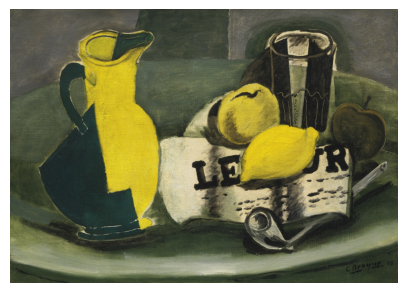

In [30]:
# TODO: possibly add confidence level
# NOTE: although I've saved copies of the test images to the images/ directory in this repository, you'll need to manually upload them to your kaggle/working directory if you're using a Kaggle remote Jupyter server. If you've cloned this repository entirely locally, use 'images/image-name.jpg' in the lines below.

learn = load_learner('painting_classifier_v1.pkl')

img = PILImage.create('painting-test-8.jpg') # create the image from the directory
classify_painting,_,probs = learn.predict(img)
print(f"This is a {classify_painting} painting.")
show_image(img) # output the image itself

# Notice that for 'painting-test-3.jpeg', which is a painting by modern artist Karen Hale, it decides that it's a Turner painting. Interesting to see what the model chooses when given unfamiliar, but still Impressionistic, paintings.
# Additional note, right now it's giving an incorrect prediction (mondrian/whistler) for Henri Matisse's The Bees. Might have to look into this.

## Get the full classification report on the model
We use a custom function here, evaluate_model, to take care of any possible issues with validation datasets being empty, and output a complete classification report.

**As of version 2, trained on 6/26/2026, the model is still achieving a modest 0.60 accuracy**, although a few of the painting classes seem to have significantly lower precision than others. While it seems to be making mostly correct predictions when given random images, the numbers disagree, even after multiple rounds of adding data and changing image sizes. Next step: **trying a different pretrained model architecture??**

In [33]:
learn = load_learner('painting_classifier_resnet34_400perartist_384x384.pkl')

dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # split 20% of the data off for validation
    get_y=parent_label,
    item_tfms=[Resize(384, method='squish')] # 224x224 image size for capturing more fine details
).dataloaders(painting_data, bs=32)

learn.dls = dls

print("train items:", len(learn.dls.train.dataset))
print("valid items:", len(learn.dls.valid.dataset))
print("vocab:", learn.dls.vocab)

def evaluate_model(learn, test_dl=None):
    """Get detailed metrics on how the classification model is performing"""
    if test_dl is None:
        test_dl = learn.dls.valid
    elif isinstance(test_dl, DataLoaders):
        test_dl = test_dl.valid

    if len(test_dl.dataset) == 0:
        raise ValueError("test_dl is empty; cannot evaluate model performance")

    preds, targs = learn.get_preds(dl=test_dl)
    if preds is None:
        raise RuntimeError("learn.get_preds() returned None. Ensure the learner and DataLoader are valid.")

    pred_classes = preds.argmax(dim=1)

    from sklearn.metrics import classification_report, confusion_matrix

    print("=== Classification Report ===")
    print(classification_report(targs, pred_classes, target_names=learn.dls.vocab))

    return confusion_matrix(targs, pred_classes)

evaluate_model(learn)

train items: 2149
valid items: 537
vocab: ['braque', 'cassatt', 'cezanne', 'degas', 'gauguin', 'manet', 'matisse', 'mondrian', 'monet', 'morisot', 'picasso', 'pissarro', 'renoir', 'rivera', 'seurat', 'toulouse-lautrec', 'turner', 'van gogh', 'warhol', 'whistler']


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


=== Classification Report ===
                  precision    recall  f1-score   support

          braque       0.79      0.62      0.70        24
         cassatt       0.50      0.84      0.63        25
         cezanne       0.92      0.71      0.80        34
           degas       0.92      0.55      0.69        20
         gauguin       0.74      0.56      0.63        36
           manet       0.00      0.00      0.00        32
         matisse       0.71      0.62      0.67        32
        mondrian       0.95      0.95      0.95        22
           monet       0.85      0.57      0.68        30
         morisot       0.73      0.55      0.63        29
         picasso       1.00      0.54      0.70        28
        pissarro       0.89      0.47      0.62        34
          renoir       1.00      0.05      0.09        21
          rivera       1.00      0.50      0.67        20
          seurat       0.70      0.70      0.70        27
toulouse-lautrec       0.18      0.56    

array([[15,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,
         0,  0,  0,  6],
       [ 0, 21,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  1,
         0,  0,  0,  2],
       [ 0,  0, 24,  1,  1,  0,  0,  1,  0,  0,  0,  0,  0,  0,  1,  1,
         0,  0,  0,  5],
       [ 0,  1,  0, 11,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  8],
       [ 0,  2,  2,  0, 20,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  6,
         0,  0,  0,  5],
       [ 0,  2,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  4,
         1,  0,  0, 24],
       [ 1,  1,  0,  0,  4,  1, 20,  0,  0,  0,  0,  0,  0,  0,  1,  1,
         0,  0,  0,  3],
       [ 0,  0,  0,  0,  0,  0,  0, 21,  1,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 0,  1,  0,  0,  1,  0,  0,  0, 17,  2,  0,  1,  0,  0,  1,  1,
         1,  0,  0,  5],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  0, 16,  0,  0,  0,  0,  0,  0,
         0,  0,  0, 12],
       [ 2,  0,  0,  0,  0,  0

In [ ]:
# Save the latest model version
learn.export('painting_classifier_resnet34_400perartist_384x384.pkl')